# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name: Group 15
Created by: Seven (Stephani) Soriano (ID: 018072470), Satyansh Rai (ID: 016323567), Karla Nguyen (ID: 017111185), Jay Barrios Abarquez (ID: 017694040)
Last updated: 3/25/2026

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

We do have some concerns with our dataset, particularly with how it handled the prices.

First, the prices are written in cents, meaning the graph axis for price looks artificially inflated. Furthermore, there are some "gimmick" games that cost an absurd amount of money, skewing the data further.

Secondly, the dataset considers games that are "Free" as having Null prices rather than costing `$0`. To address all of these issues, we plan to divide the price columns by 100 to standardize it to dollars and filter any games that are out of a typical game's price range (this can be defined by the user later, but for now we want to set it to `$100`).

Finally, to address the null values, we plan to replace all Null prices for free games with `$0` so they can be accurately included in our dataset.

In [11]:
### Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Import data
steam_games = pd.read_csv("steam_games_small.csv")

### Here are the steps for the cleaned data
steam_clean = steam_games.copy()
## Replace all null values (free games) with $0
steam_clean["mat_initial_price"] = steam_clean["mat_initial_price"].fillna(0)
steam_clean["mat_final_price"] = steam_clean["mat_final_price"].fillna(0)
## Convert prices from cents to dollars
steam_clean["mat_initial_price"] = steam_clean["mat_initial_price"] / 100
steam_clean["mat_final_price"] = steam_clean["mat_final_price"] / 100
## Remove games with prices over $100
steam_clean = steam_clean[
    (steam_clean["mat_initial_price"] <= 100) &
    (steam_clean["mat_final_price"] <= 100)
]
## Reset the index
steam_clean = steam_clean.reset_index(drop=True)

## Make sure the cleaning worked
steam_clean.info()

# ## Save to a new csv for future use (can leave commented out)
# steam_clean.to_csv("steam_clean_under_100.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238619 entries, 0 to 238618
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   name                   238615 non-null  object 
 1   release_date           201832 non-null  object 
 2   mat_initial_price      238619 non-null  float64
 3   mat_final_price        238619 non-null  float64
 4   metacritic_score       5239 non-null    float64
 5   recommendations_total  22325 non-null   float64
 6   is_free                238619 non-null  bool   
dtypes: bool(1), float64(4), object(2)
memory usage: 11.2+ MB


### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

# **Do higher priced games get better reviews?**

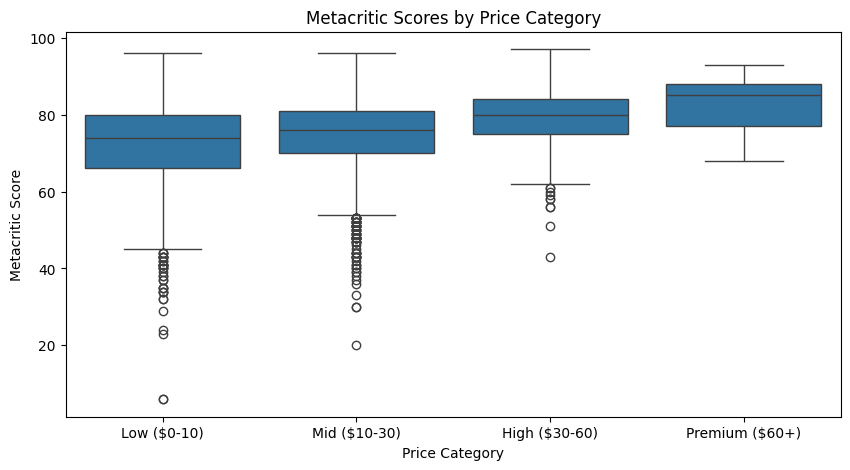

In [12]:
# Create price bins
steam_clean["price_category"] = pd.cut(
    steam_clean["mat_final_price"],
    bins=[0, 10, 30, 60, 100],
    labels=["Low ($0-10)", "Mid ($10-30)", "High ($30-60)", "Premium ($60+)"]
)

# Create boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=steam_clean, x="price_category", y="metacritic_score")

plt.title("Metacritic Scores by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Metacritic Score")

plt.show()

### Q3: Come up with a another unique question. This question must use map() or apply()

In [13]:
# Your code here . . .

### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [14]:
# Your code here . . .

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

In [15]:
# Your code here . . .